In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

print("Dataset loaded successfully!")
print("Shape:", data.shape)

print("\nFirst 5 rows:")
print(data.head())

Dataset loaded successfully!
Shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   



In [3]:
print("Data types:")
print(data.dtypes)

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [4]:
numeric_columns = data.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Numeric columns:")
print(numeric_columns)

Numeric columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges']


In [5]:
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"], errors="coerce"
)

data["TotalCharges"] = data["TotalCharges"].fillna(
    data["TotalCharges"].median()
)

print("TotalCharges converted successfully!")
print(data["TotalCharges"].dtype)

TotalCharges converted successfully!
float64


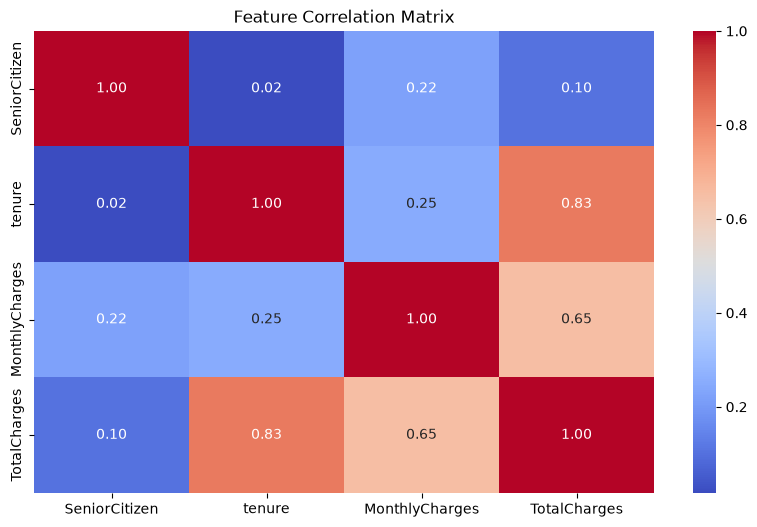

In [6]:
correlation_data = data.select_dtypes(
    include=["int64", "float64"]
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

In [7]:
data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0})

print("Target variable converted successfully!")
print(data["Churn"].value_counts())

Target variable converted successfully!
Churn
0    5174
1    1869
Name: count, dtype: int64


In [8]:
model_data = data.drop(columns=["customerID"])

categorical_columns = model_data.select_dtypes(
    include=["object"]
).columns

model_data = pd.get_dummies(
    model_data,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Encoding completed!")
print("New dataset shape:", model_data.shape)

Encoding completed!
New dataset shape: (7043, 31)


C:\Users\aatik\AppData\Local\Temp\ipykernel_5716\464725802.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = model_data.select_dtypes(


In [9]:
X = model_data.drop(columns=["Churn"])
y = model_data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features: (5634, 30)
Testing features: (1409, 30)


In [10]:
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.8041163946061036


c:\Users\aatik\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(baseline_model.coef_[0])
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Important Features:")
print(feature_importance.head(15))

Top 15 Important Features:
                           Feature  Importance
25               Contract_Two year    1.330567
10     InternetService_Fiber optic    0.745318
24               Contract_One year    0.681413
7                 PhoneService_Yes    0.444916
13              OnlineSecurity_Yes    0.438534
19                 TechSupport_Yes    0.388200
26            PaperlessBilling_Yes    0.381613
28  PaymentMethod_Electronic check    0.381070
9                MultipleLines_Yes    0.276856
6                   Dependents_Yes    0.224696
21                 StreamingTV_Yes    0.201128
23             StreamingMovies_Yes    0.199967
15                OnlineBackup_Yes    0.188402
8   MultipleLines_No phone service    0.157954
0                    SeniorCitizen    0.150508


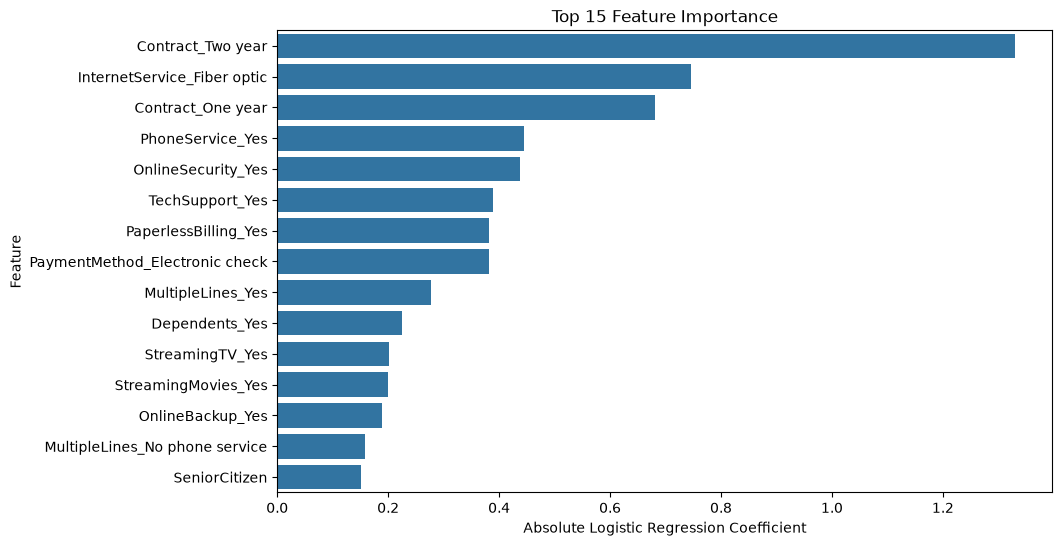

In [12]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importance")
plt.xlabel("Absolute Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.show()

In [13]:
selected_features = feature_importance.head(10)["Feature"].tolist()

print("Selected Features:")
for feature in selected_features:
    print("-", feature)

print("\nNumber of selected features:", len(selected_features))

Selected Features:
- Contract_Two year
- InternetService_Fiber optic
- Contract_One year
- PhoneService_Yes
- OnlineSecurity_Yes
- TechSupport_Yes
- PaperlessBilling_Yes
- PaymentMethod_Electronic check
- MultipleLines_Yes
- Dependents_Yes

Number of selected features: 10


In [14]:
X_selected = X[selected_features]

X_selected_train, X_selected_test, y_selected_train, y_selected_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Original number of features:", X.shape[1])
print("Selected number of features:", X_selected.shape[1])

Original number of features: 30
Selected number of features: 10


In [15]:
selected_model = LogisticRegression(max_iter=1000)

selected_model.fit(
    X_selected_train,
    y_selected_train
)

selected_predictions = selected_model.predict(
    X_selected_test
)

selected_accuracy = accuracy_score(
    y_selected_test,
    selected_predictions
)

print("Selected Features Accuracy:", selected_accuracy)

Selected Features Accuracy: 0.7764371894960965


In [16]:
performance_comparison = pd.DataFrame({
    "Model": [
        "Baseline - All Features",
        "Feature Selection - Top 10"
    ],
    "Number of Features": [
        X.shape[1],
        X_selected.shape[1]
    ],
    "Accuracy": [
        baseline_accuracy,
        selected_accuracy
    ]
})

print(performance_comparison)

                        Model  Number of Features  Accuracy
0     Baseline - All Features                  30  0.804116
1  Feature Selection - Top 10                  10  0.776437


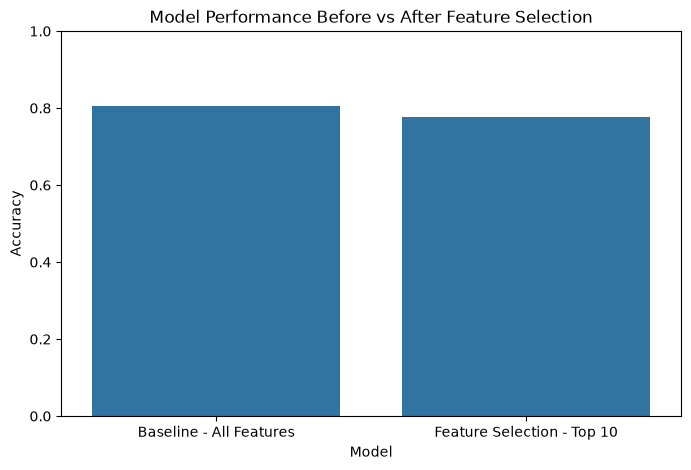

In [17]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=performance_comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Performance Before vs After Feature Selection")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

In [18]:
performance_comparison.to_csv(
    "feature_selection_comparison.csv",
    index=False
)

print("Comparison report saved successfully!")

Comparison report saved successfully!


In [19]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


In [20]:
selected_features_df = pd.DataFrame({
    "Selected Feature": selected_features
})

selected_features_df.to_csv(
    "selected_features.csv",
    index=False
)

print("Selected features saved successfully!")

Selected features saved successfully!


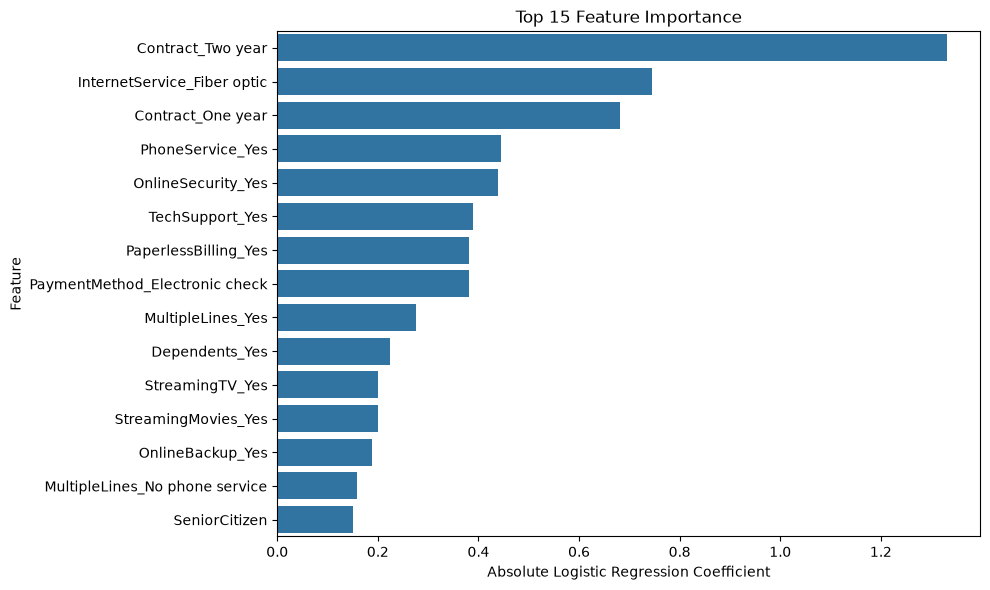

Feature importance visualization saved successfully!


In [21]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importance")
plt.xlabel("Absolute Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig("feature_importance.png", dpi=300)
plt.show()

print("Feature importance visualization saved successfully!")

In [22]:
print("FEATURE SELECTION ANALYSIS")
print("-" * 40)

print(f"Baseline features: {X.shape[1]}")
print(f"Selected features: {X_selected.shape[1]}")

print(f"\nBaseline accuracy: {baseline_accuracy:.4f}")
print(f"Selected features accuracy: {selected_accuracy:.4f}")

if selected_accuracy > baseline_accuracy:
    print("\nResult: Accuracy improved after feature selection.")
elif selected_accuracy < baseline_accuracy:
    print("\nResult: Accuracy decreased slightly after feature selection.")
else:
    print("\nResult: Accuracy remained the same after feature selection.")

print("\nSelected features:")
for feature in selected_features:
    print("-", feature)

FEATURE SELECTION ANALYSIS
----------------------------------------
Baseline features: 30
Selected features: 10

Baseline accuracy: 0.8041
Selected features accuracy: 0.7764

Result: Accuracy decreased slightly after feature selection.

Selected features:
- Contract_Two year
- InternetService_Fiber optic
- Contract_One year
- PhoneService_Yes
- OnlineSecurity_Yes
- TechSupport_Yes
- PaperlessBilling_Yes
- PaymentMethod_Electronic check
- MultipleLines_Yes
- Dependents_Yes
